
Top 20 important wavelengths:
      wavelength  coefficient   abs_coef
1058  5912.94714    60.009840  60.009840
1057  5916.80425    59.437330  59.437330
1485  4265.96187   -57.567329  57.567329
1059  5909.09004    57.119783  57.119783
1056  5920.66136    57.103433  57.103433
1486  4262.10476   -57.014430  57.014430
1055  5924.51847    55.507355  55.507355
1487  4258.24765   -53.133482  53.133482
1054  5928.37558    52.821403  52.821403
1060  5905.23293    52.197672  52.197672
1484  4269.81897   -52.133554  52.133554
1439  4443.38885    51.230784  51.230784
1438  4447.24596    50.438236  50.438236
1488  4254.39054   -49.634646  49.634646
1440  4439.53174    49.518911  49.518911
1220  5288.09559   -48.230936  48.230936
1219  5291.95269   -48.023534  48.023534
1061  5901.37582    47.273235  47.273235
1483  4273.67608   -46.395142  46.395142
1441  4435.67463    46.230893  46.230893


/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.279e+05, tolerance: 3.242e+02
  model = cd_fast.enet_coordinate_descent(


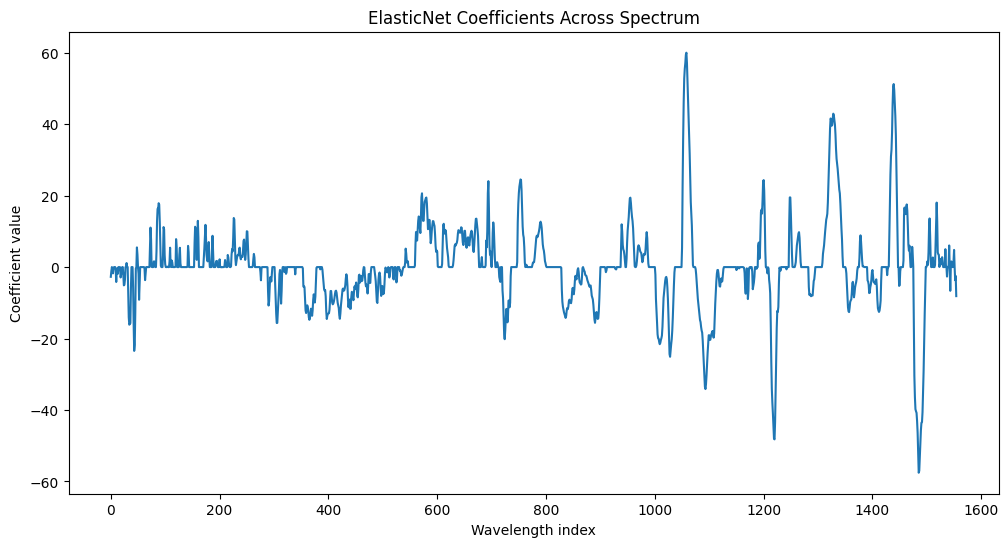


Selected wavelengths: 1064
Total wavelengths: 1555


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline


# ================================
# Load data
# ================================

train = pd.read_csv("../data/train.csv", encoding="cp932")

target = "含水率"

spectral_cols = [
    c for c in train.columns
    if c not in ["sample number","species number","樹種","含水率"]
]

X = train[spectral_cols]
y = train[target]


# ================================
# Fit best ElasticNet model
# ================================

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.002,
        l1_ratio=0.9,
        max_iter=100000,
        random_state=42
    ))
])

model.fit(X, y)

elastic = model.named_steps["model"]

coefficients = elastic.coef_


# ================================
# Create coefficient dataframe
# ================================

coef_df = pd.DataFrame({
    "wavelength": spectral_cols,
    "coefficient": coefficients
})

coef_df["abs_coef"] = np.abs(coef_df["coefficient"])

coef_df = coef_df.sort_values("abs_coef", ascending=False)


# ================================
# Print strongest wavelengths
# ================================

print("\nTop 20 important wavelengths:")
print(coef_df.head(20))


# ================================
# Plot coefficient distribution
# ================================

plt.figure(figsize=(12,6))

plt.plot(coefficients)

plt.title("ElasticNet Coefficients Across Spectrum")
plt.xlabel("Wavelength index")
plt.ylabel("Coefficient value")

plt.show()


# ================================
# Count selected features
# ================================

selected = np.sum(coefficients != 0)

print("\nSelected wavelengths:", selected)
print("Total wavelengths:", len(coefficients))